In [6]:
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from stable_baselines3 import PPO, A2C, DDPG, SAC, TD3
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import BaseCallback
import os
import optuna
import json
import re

In [3]:
pip install alpha_vantage


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
from alpha_vantage.timeseries import TimeSeries
import time
API_KEY = "YI4C9EA20IKE29K4" # note: i would definitely hide my api key if this is for public :))

# Download stocks data

In [8]:
# List of stocks in the Dow Jones 30. I was only able to download 25 of them since I 
# only have 25 free requests 
tickers = [
    'MMM', 'AXP', 'AAPL', 'BA', 'CAT', 'CVX', 'CSCO', 'KO', 'DIS', 'DOW',
    'GS', 'HD', 'IBM', 'INTC', 'JNJ', 'JPM', 'MCD', 'MRK', 'MSFT', 'NKE',
    'PFE', 'PG', 'TRV', 'UNH', 'UTX', 'VZ', 'V', 'WBA', 'WMT', 'XOM'
]
tickers.remove('DOW')
tickers.remove('UTX')

# Get historical data and save it
def fetch_stock_data(tickers, outputsize='full'):
    ts = TimeSeries(key=API_KEY, output_format='pandas')
    stock_data = {}

    for i, ticker in enumerate(tickers):
        try:
            print(f"Fetching {ticker}...")
            data, _ = ts.get_daily(symbol=ticker, outputsize=outputsize)

            data = data.rename(columns={
                '1. open': 'Open',
                '2. high': 'High',
                '3. low': 'Low',
                '4. close': 'Close',
                '5. volume': 'Volume'
            })
            data.index = pd.to_datetime(data.index)
            data = data.sort_index()
            stock_data[ticker] = data

            # Save CSV so I can use it later 
            data.to_csv(f"{ticker}_daily.csv")

            # Respect API rate limits (only 5 requests/minute) because I'm on free tier !!! 
            if i % 5 == 4:
                print("Waiting 60 seconds to respect API limits...")
                time.sleep(60)
        except Exception as e:
            print(f"Error fetching {ticker}: {e}")

    return stock_data

stock_data = fetch_stock_data(tickers)

Fetching MMM...
Fetching AXP...
Fetching AAPL...
Fetching BA...
Fetching CAT...
Waiting 60 seconds to respect API limits...
Fetching CVX...
Fetching CSCO...
Fetching KO...
Fetching DIS...
Fetching GS...
Waiting 60 seconds to respect API limits...
Fetching HD...
Fetching IBM...
Fetching INTC...
Fetching JNJ...
Fetching JPM...
Waiting 60 seconds to respect API limits...
Fetching MCD...
Fetching MRK...
Fetching MSFT...
Fetching NKE...
Fetching PFE...
Waiting 60 seconds to respect API limits...
Fetching PG...
Fetching TRV...
Fetching UNH...
Fetching VZ...
Fetching V...
Waiting 60 seconds to respect API limits...
Fetching WBA...
Fetching WMT...
Error fetching WMT: We have detected your API key as YI4C9EA20IKE29K4 and our standard API rate limit is 25 requests per day. Please subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to instantly remove all daily rate limits.
Fetching XOM...
Error fetching XOM: We have detected your API key as YI4C9EA20IKE29K4 and our stan

I ran out of API requests so for now I will work with 25 tickers

# Dividing data into Training, Validation, Test Dataset

- IBM Training Set: (1763, 5)
- IBM Validation Set: (252, 5)
- IBM Test Set: (842, 5)


,Open,High,Low,Close,Volume
date,,,,,
1999-11-01,98.50,98.81,96.37,96.75,9551800.0
1999-11-02,96.75,96.81,93.69,94.81,11105400.0
1999-11-03,95.87,95.94,93.50,94.37,10369100.0
1999-11-04,94.44,94.44,90.00,91.56,16697600.0
1999-11-05,92.75,92.94,90.19,90.25,13737600.0


,Open,High,Low,Close,Volume
date,,,,,
2025-05-06,247.76,250.19,246.110,249.12,2900556.0
2025-05-07,249.45,254.47,248.832,253.37,3400001.0
2025-05-08,255.00,256.52,253.250,254.14,3637012.0
2025-05-09,252.51,253.00,247.640,249.20,2901346.0
2025-05-12,251.89,253.81,244.650,253.80,4590152.0


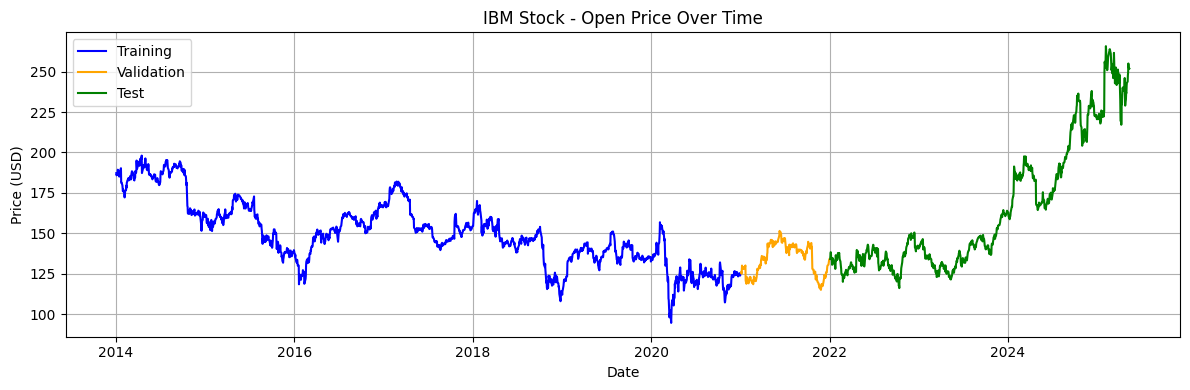

In [11]:
# Splitting data into traing, validation and test sets
training_range = ('2014-01-01', '2020-12-31')
validation_range = ('2021-01-01', '2021-12-31')
test_range = ('2022-01-01', '2025-05-12')

# Initialize dictionaries for splits
training_data, validation_data, test_data = {}, {}, {}

# Apply split for each stock
for ticker, df in stock_data.items():
    training_data[ticker] = df.loc[training_range[0]:training_range[1]]
    validation_data[ticker] = df.loc[validation_range[0]:validation_range[1]]
    test_data[ticker] = df.loc[test_range[0]:test_range[1]]

# Check IBM as an example
ticker = 'IBM'
print(f"- {ticker} Training Set: {training_data[ticker].shape}")
print(f"- {ticker} Validation Set: {validation_data[ticker].shape}")
print(f"- {ticker} Test Set: {test_data[ticker].shape}")

# Display first few rows and last few rows of the data
display(stock_data[ticker].head())
display(stock_data[ticker].tail())

# Ploting open prices across all periods from 2014 to 2025
plt.figure(figsize=(12, 4))
plt.plot(training_data[ticker].index, training_data[ticker]['Open'], label='Training', color='blue')
plt.plot(validation_data[ticker].index, validation_data[ticker]['Open'], label='Validation', color='orange')
plt.plot(test_data[ticker].index, test_data[ticker]['Open'], label='Test', color='green')
plt.title(f'{ticker} Stock - Open Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Adding some techincal indicators to our dataset

In [14]:
# add technical indicators
def add_techin(df):
    df = df.copy()

    # MACD (Moving Average Convergence Divergence)
    df['EMA12'] = df['Close'].ewm(span=12, adjust=False).mean() # 12-period exponential moving average
    df['EMA26'] = df['Close'].ewm(span=26, adjust=False).mean() #26-period EMA
    df['MACD'] = df['EMA12'] - df['EMA26'] # On charts MACD line = EMA12 - EMA26
    df['Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

    # RSI (Relative Strength Index)
    delta = df['Close'].diff() # price change between current and previous close
    gain = delta.where(delta > 0, 0).rolling(window=14).mean() # average gain over 14 periods
    loss = -delta.where(delta < 0, 0).rolling(window=14).mean() # average loss over 14 periods
    rs = gain / loss #relative strength
    df['RSI'] = 100 - (100 / (1 + rs)) #rsi formula i searched online

    # CCI (Commodity Channel Index)
    tp = (df['High'] + df['Low'] + df['Close']) / 3 #typical price
    sma_tp = tp.rolling(window=20).mean()
    mad = tp.rolling(window=20).apply(lambda x: np.mean(np.abs(x - x.mean())), raw=True)
    df['CCI'] = (tp - sma_tp) / (0.015 * mad)

    # ADX (Average Directional Index)
    high_diff = df['High'].diff()
    low_diff = df['Low'].diff()
    df['+DM'] = np.where((high_diff > low_diff) & (high_diff > 0), high_diff, 0)
    df['-DM'] = np.where((low_diff > high_diff) & (low_diff > 0), low_diff, 0)
    #this is the true range
    tr = pd.concat([
        df['High'] - df['Low'],
        (df['High'] - df['Close'].shift(1)).abs(),
        (df['Low'] - df['Close'].shift(1)).abs()
    ], axis=1).max(axis=1)
    #average true range
    atr = tr.ewm(span=14, adjust=False).mean()
    df['+DI'] = 100 * df['+DM'].ewm(span=14, adjust=False).mean() / atr
    df['-DI'] = 100 * df['-DM'].ewm(span=14, adjust=False).mean() / atr
    dx = 100 * (df['+DI'] - df['-DI']).abs() / (df['+DI'] + df['-DI'])
    df['ADX'] = dx.ewm(span=14, adjust=False).mean()

    # Clean up and I keep only relevant features
    df.dropna(inplace=True)
    return df[['Open', 'High', 'Low', 'Close', 'Volume', 'MACD', 'Signal', 'RSI', 'CCI', 'ADX']]


In [15]:
# Apply indicator calculation to all splits
for dataset, name in zip([training_data, validation_data, test_data], ['Training', 'Validation', 'Test']):
    for ticker in dataset:
        dataset[ticker] = add_techin(dataset[ticker])
    print(f"{name} data sample for {ticker}: {dataset[ticker].shape}")

# look at some examples to see what they look like
display(test_data[ticker].head())


Training data sample for WBA: (1725, 10)
Validation data sample for WBA: (214, 10)
Test data sample for WBA: (804, 10)


,Open,High,Low,Close,Volume,MACD,Signal,RSI,CCI,ADX
date,,,,,,,,,,
2022-02-28,45.600,46.40,45.34,46.09,7033206.0,-1.026320,-0.775639,32.435597,-97.234377,41.688907
2022-03-01,45.910,46.08,44.59,45.01,5291965.0,-1.097529,-0.840017,23.206278,-113.773171,45.622239
2022-03-02,45.260,46.27,44.92,46.15,6247204.0,-1.049872,-0.881988,30.527383,-80.059376,49.741107
2022-03-03,46.755,47.01,46.19,46.72,7234332.0,-0.955099,-0.896610,37.060041,-37.221006,54.722352
2022-03-04,46.110,47.79,46.05,47.72,9602408.0,-0.790190,-0.875326,45.167653,-6.700217,52.999801


# Create The Trading Environment

In [16]:
class StockTradingEnv(gym.Env):
    metadata = {'render_modes': ['human']}

    def __init__(self, stock_data, transaction_cost_percent=0.005, initial_balance=100000, render_mode=None):
        super().__init__()
        self.render_mode = render_mode
        # Store input and initialize
        self.stock_data = {ticker: df for ticker, df in stock_data.items() if not df.empty}
        self.tickers = list(self.stock_data.keys())
        if not self.tickers:
            raise ValueError("Uh oh no valid stock data provided.")

        # Setting up the environment
        sample_df = next(iter(self.stock_data.values()))
        self.n_features = sample_df.shape[1]
        self.num_assets = len(self.tickers)
        self.initial_balance = initial_balance
        self.transaction_cost_percent = transaction_cost_percent
        self.short = False  # Set to True if allowing shorting

        # Here we define action and observation spaces
        # action space is continous value in range [-1,1] for each assets
        self.action_space = spaces.Box(low=-1, high=1, shape=(self.num_assets,), dtype=np.float32)
        # observation space includes concatenated features from each stock + balance + holdings + net worth + max worth + step
        obs_size = self.n_features * self.num_assets + 2 + self.num_assets + 2  # price, balance, holdings, net worth, max worth, step
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(obs_size,), dtype=np.float32)

        # determine max steps in the episode (min length across all stock series)
        self.max_steps = max(0, min(len(df) for df in self.stock_data.values()) - 1)
        #initialize episode state
        self.reset()

    def reset(self, seed=None, options=None):
        #reset financial state
        super().reset(seed=seed)
        self.balance = self.initial_balance
        self.net_worth = self.initial_balance
        self.prev_net_worth = self.initial_balance 
        self.max_net_worth = self.initial_balance
        self.shares_held = {ticker: 0 for ticker in self.tickers}
        self.total_shares_sold = {ticker: 0 for ticker in self.tickers}
        self.total_sales_value = {ticker: 0 for ticker in self.tickers}
        self.current_step = 0
    
        return self._next_observation(), {}

    def _next_observation(self):
        # observation vector for the current timestep
        obs = np.zeros(self.observation_space.shape[0])
        idx = 0
        #add stock feature values from each ticker
        for ticker in self.tickers:
            df = self.stock_data[ticker]
            obs[idx:idx+self.n_features] = df.iloc[min(self.current_step, len(df)-1)].values
            idx += self.n_features
        # append balance, shares held, net worth, step
        obs[-4 - self.num_assets] = self.balance
        obs[-3 - self.num_assets:-3] = [self.shares_held[t] for t in self.tickers]
        obs[-3] = self.net_worth
        obs[-2] = self.max_net_worth
        obs[-1] = self.current_step

        return obs

    def step(self, actions):
        # step 1 day forward
        self.current_step += 1
        done = self.current_step > self.max_steps
        total_transaction_cost = 0
        close_prices = {}
        # perform actions for each asset
        for i, ticker in enumerate(self.tickers):
            df = self.stock_data[ticker]
            if self.current_step >= len(df):
                current_day = df.iloc[-1]
            else:
                current_day = df.iloc[self.current_step]
    
            open_price, close_price = current_day['Open'], current_day['Close']
            action_price = open_price if self.short else close_price
            action = actions[i]
            close_prices[ticker] = close_price

            if action > 0:  # Buy
                shares = int(self.balance * action / action_price)
                cost = shares * action_price
                transaction_cost = cost * self.transaction_cost_percent
                total_transaction_cost += transaction_cost
    
                self.balance -= (cost + transaction_cost)
                self.shares_held[ticker] += shares
    
            elif action < 0:  # Sell
                shares = int(self.shares_held[ticker] * abs(action))
                sale = shares * action_price
                transaction_cost = sale * self.transaction_cost_percent
                total_transaction_cost += transaction_cost
    
                self.balance += (sale - transaction_cost)
                self.shares_held[ticker] -= shares
                self.total_shares_sold[ticker] += shares
                self.total_sales_value[ticker] += sale

        # Update net worth
        self.net_worth = self.balance + sum(self.shares_held[t] * close_prices[t] for t in self.tickers)
        self.max_net_worth = max(self.max_net_worth, self.net_worth)
    
        # Reward: delta net worth (change in networth) - transaction penalty
        reward = (self.net_worth - self.prev_net_worth) - total_transaction_cost * 1.0
        self.prev_net_worth = self.net_worth
        # if we've exceeded steps or lost all money episode end
        return self._next_observation(), reward, done or self.net_worth <= 0, False, {}


    def render(self, render_mode='human'):
        # summary info at each step
        profit = self.net_worth - self.initial_balance
        #print(f"Step: {self.current_step}\nBalance: {self.balance:.2f}\nNet Worth: {self.net_worth:.2f}\nProfit: {profit:.2f}")
        #for ticker in self.tickers:
            #print(f"{ticker} Shares Held: {self.shares_held[ticker]}")

    def close(self):
        pass


# Custom callback logs the policy gradient loss 

In [17]:
class PolicyGradientLossCallback(BaseCallback):
    def __init__(self, verbose=0):
        # initialize the base callback and store losses in a list 
        super().__init__(verbose)
        self.losses = []

    def _on_step(self):
        # I'll call this after each call to model.learn().step()
        # we can retrieve the current policy gradient loss from the logger
        loss = self.model.logger.name_to_value.get("train/policy_gradient_loss")
        if loss is not None:
            self.losses.append(loss)
        return True

    def _on_training_end(self):
        # This is called automatically when training finishes to visualize losses of each model
        plt.figure(figsize=(12, 4))
        plt.plot(self.losses, label='Policy Gradient Loss')
        plt.title(f'{self.model.__class__.__name__} - Training Loss')
        plt.xlabel("Steps")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)
        plt.show()


# A Base Trading Agent for 5 different RL trading agents

In [18]:
# Base class for trading agents using Stable-Baselines3 algorithms
class BaseTradingAgent:
    def __init__(self, algo_cls, env, total_timesteps=0, threshold=0.1, model_path=None):
        # algo_cls: RL algorithm class. I will use 5 algos, including PPO, A2C, DDPG, SAC, TD3 
        # total_timesteps: number of timesteps to train, I will trained and tuned these models
        # threshold: action threshold for making decisions like buy/sell/hold
        # model_path: I want to save and load the model to save time 
        self.algo_cls = algo_cls
        self.threshold = threshold
        self.callback = PolicyGradientLossCallback()

        if model_path and os.path.exists(model_path + ".zip"):
            self.model = algo_cls.load(model_path, env=env)
        else:
            self.model = algo_cls("MlpPolicy", env, verbose=0)
            if total_timesteps > 0:
                self.model.learn(total_timesteps=total_timesteps, callback=self.callback)
                if model_path:
                    self.model.save(model_path)

    def predict(self, obs):
        action, _ = self.model.predict(obs, deterministic=True)
        return action

    def action_to_recommendation(self, action):
        # Convert continuous actions into discrete trade signals
        return ['buy' if a > self.threshold else 'sell' if a < -self.threshold else 'hold' for a in action]

    def validate(self, env, n_steps=1000):
        obs = env.reset()
        total_rewards = 0
        for _ in range(n_steps):
            action, _ = self.model.predict(obs)
            obs, reward, done, _ = env.step(action)
            total_rewards += reward
            if done:
                obs = env.reset()
        print(f'{self.model.__class__.__name__} Validation Reward: {total_rewards}')

    def save(self, path):
        self.model.save(path)

    @classmethod
    def load(cls, path, env, threshold=0.1):
        # load agent from disk 
        model = cls.__new__(cls)
        model.model = cls.model_cls.load(path, env=env)
        model.env = env
        model.threshold = threshold
        return model

In [19]:
# Mapping from name to SB3 class
ALGO_MAP = {
    "ppo": PPO,
    "a2c": A2C,
    "ddpg": DDPG,
    "sac": SAC,
    "td3": TD3
}

class TunableTradingAgent(BaseTradingAgent): # I want to tune these models, all of these are basically the same
    def __init__(self, model_cls, env, total_timesteps=10000, threshold=0.1, model_path=None, best_params=None):
        self.model_cls = model_cls
        self.env = env
        self.threshold = threshold

        if model_path and os.path.exists(model_path):
            self.model = model_cls.load(model_path, env=env)
        else:
            self.model = model_cls("MlpPolicy", env, verbose=0, **(best_params or {}))
            self.model.learn(total_timesteps=total_timesteps)
            if model_path:
                self.model.save(model_path)

    def predict(self, obs):
        action, _ = self.model.predict(obs, deterministic=True)
        return action

    def validate(self, env, steps=1000):
        obs = env.reset()
        total_rewards = 0
        for _ in range(steps):
            action = self.predict(obs)
            obs, reward, done, _ = env.step(action)
            total_rewards += reward
            if done:
                obs = env.reset()
        print(f"Validation Reward: {total_rewards}")
        return total_rewards

    @classmethod
    def tune_hyperparams(cls, algo_name, train_env, val_env, n_trials=20):
        def tune(trial):
            kwargs = {
                "learning_rate": trial.suggest_loguniform("learning_rate", 1e-5, 1e-3),
                "gamma": trial.suggest_uniform("gamma", 0.9, 0.999),
            }
            if algo_name in ["ddpg", "td3", "sac"]:
                kwargs.update({
                    "buffer_size": trial.suggest_int("buffer_size", 10000, 100000),
                    "batch_size": trial.suggest_int("batch_size", 32, 256),
                    "tau": trial.suggest_uniform("tau", 0.005, 0.05)
                })
            model = ALGO_MAP[algo_name]("MlpPolicy", train_env, verbose=0, **kwargs)
            model.learn(total_timesteps=5000)
            return cls.evaluate_model(model, val_env)

        study = optuna.create_study(direction="maximize")
        study.optimize(tune, n_trials=n_trials)
        print(f"Best parameters for {algo_name.upper()}: {study.best_params}")
        return study.best_params

    @staticmethod
    def evaluate_model(model, env, steps=500):
        obs = env.reset()
        total_rewards = 0
        for _ in range(steps):
            action, _ = model.predict(obs)
            obs, reward, done, _ = env.step(action)
            total_rewards += reward
            if done:
                obs = env.reset()
        return total_rewards


# Individual Trading Agents
1. Proximal Policy Optimization
2. Advantage Actor-Critic
3. Deep Deterministic Policy Gradient
4. Soft Actor-Critic
5. Twin Delayed Deep Deterministic Policy Gradient

In [20]:
class PPOAgent(BaseTradingAgent):
    model_cls = PPO
    def __init__(self, env, total_timesteps=0, threshold=0.1, model_path=None):
        super().__init__(PPO, env, total_timesteps, threshold, model_path)

class A2CAgent(BaseTradingAgent):
    model_cls = A2C
    def __init__(self, env, total_timesteps=0, threshold=0.1, model_path=None):
        super().__init__(A2C, env, total_timesteps, threshold, model_path)

class DDPGAgent(BaseTradingAgent):
    model_cls = DDPG
    def __init__(self, env, total_timesteps=0, threshold=0.1, model_path=None):
        super().__init__(DDPG, env, total_timesteps, threshold, model_path)

class SACAgent(BaseTradingAgent):
    model_cls = SAC
    def __init__(self, env, total_timesteps=0, threshold=0.1, model_path=None):
        super().__init__(SAC, env, total_timesteps, threshold, model_path)

class TD3Agent(BaseTradingAgent):
    model_cls = TD3
    def __init__(self, env, total_timesteps=0, threshold=0.1, model_path=None):
        super().__init__(TD3, env, total_timesteps, threshold, model_path)


# EnsembleAgent
Combines the predictions from multiple individual models (PPO, A2C, DDPG, SAC, and TD3) to make a final decision. This ensemble approach aims to leverage the strengths of each algorithm.

In [21]:
class EnsembleAgent:
    def __init__(self, agents, threshold=0.1):
        self.agents = agents # list of trained individual agent instances such as PPO, A2C, ...
        self.threshold = threshold # threshold to decide buy/sell/hold

    def predict(self, obs):
        # first get predictions from all individual agents
        actions = [agent.predict(obs) for agent in self.agents]
        # we return the average action (ensemble voting strategy)
        return np.mean(actions, axis=0)

    def action_to_recommendation(self, action):
        # convert the ensemble's continuous actions to discrete recommendations
        action = np.squeeze(np.array(action)) 
        return ['buy' if a > self.threshold else 'sell' if a < -self.threshold else 'hold' for a in action]

    def validate(self, env, steps=1000):
        obs = env.reset()
        total_rewards = 0
        for _ in range(steps):
            action = self.predict(obs)
            obs, reward, done, _ = env.step(action)
            total_rewards += reward
            if done:
                obs = env.reset()
        print(f"EnsembleAgent Validation Reward: {total_rewards}")

    def save(self, folder_path):
        os.makedirs(folder_path, exist_ok=True)
        for i, agent in enumerate(self.agents):
            agent.save(os.path.join(folder_path, f"agent_{i}"))

    def load(self, folder_path, agent_classes, envs):
        self.agents = []
        for i, (cls, env) in enumerate(zip(agent_classes, envs)):
            path = os.path.join(folder_path, f"agent_{i}")
            agent = cls(env, total_timesteps=0) 
            agent.load(path, env)
            self.agents.append(agent)


In [22]:
# Function to create the environment and train the agents
def create_env_and_train_agents(train_data, val_data, total_timesteps, threshold, model_dir="trained_models", use_optuna=False, n_trials=10):
    os.makedirs(model_dir, exist_ok=True)

    train_env = DummyVecEnv([lambda: StockTradingEnv(train_data)])
    val_env = DummyVecEnv([lambda: StockTradingEnv(val_data)])

    def get_or_tune(agent_cls, model_cls, name):
        path = os.path.join(model_dir, f"{name}_model.zip")
        config_path = os.path.join(model_dir, f"{name}_config.json")
        current_config = {
            "total_timesteps": total_timesteps,
            "threshold": threshold,
            "use_optuna": use_optuna,
            "n_trials": n_trials if use_optuna else None
        }
        def config_matches():
            if not os.path.exists(config_path):
                return False
            with open(config_path, "r") as f:
                saved_config = json.load(f)
            return saved_config == current_config
        # If valid model exists and config matches -> load it
        if os.path.exists(path):
            print(f"Loading {name.upper()} from disk...")
            return agent_cls.load(path=path, env=train_env, threshold=threshold)
        # Otherwise -> train or tune and save model + config
        if use_optuna:
            print(f"Tuning {name.upper()} with Optuna...")
            best_params = TunableTradingAgent.tune_hyperparams(
                algo_name=name,
                train_env=train_env,
                val_env=val_env,
                n_trials=n_trials
            )
            agent = TunableTradingAgent(model_cls, train_env, best_params=best_params, threshold=threshold)
        else:
            print(f"Training {name.upper()} with default parameters...")
            agent = agent_cls(env=train_env, total_timesteps=total_timesteps, threshold=threshold)
        agent.model.learn(total_timesteps=total_timesteps)
        agent.save(path)
        with open(config_path, "w") as f:
            json.dump(current_config, f)
        return agent

    # Train or load individual agents
    ppo_agent = get_or_tune(PPOAgent, PPO, "ppo")
    a2c_agent = get_or_tune(A2CAgent, A2C, "a2c")
    ddpg_agent = get_or_tune(DDPGAgent, DDPG, "ddpg")
    sac_agent = get_or_tune(SACAgent, SAC, "sac")
    td3_agent = get_or_tune(TD3Agent, TD3, "td3")

    # Validate each agent
    for agent in [ppo_agent, a2c_agent, ddpg_agent, sac_agent, td3_agent]:
        agent.validate(val_env)

    # Ensemble agent part 
    ensemble_agent = EnsembleAgent(
        agents=[ppo_agent, a2c_agent, ddpg_agent, sac_agent, td3_agent],
        threshold=threshold)
    ensemble_agent.validate(val_env)

    return train_env, val_env, ppo_agent, a2c_agent, ddpg_agent, sac_agent, td3_agent, ensemble_agent

# Function to visualize portfolio changes
def visualize_portfolio(steps, balances, net_worths, shares_held, tickers,
                        show_balance=True, show_net_worth=True, show_shares_held=True):

    fig, axs = plt.subplots(3, figsize=(12, 18))

    # Plot the balance
    if show_balance:
        axs[0].plot(steps, balances, label='Balance')
        axs[0].set_title('Balance Over Time')
        axs[0].set_xlabel('Steps')
        axs[0].set_ylabel('Balance')
        axs[0].legend()

    # Plot the net worth
    if show_net_worth:
        axs[1].plot(steps, net_worths, label='Net Worth', color='orange')
        axs[1].set_title('Net Worth Over Time')
        axs[1].set_xlabel('Steps')
        axs[1].set_ylabel('Net Worth')
        axs[1].legend()

    # Plot the shares held
    if show_shares_held:
        for ticker in tickers:
            axs[2].plot(steps, shares_held[ticker], label=f'Shares Held: {ticker}')
        axs[2].set_title('Shares Held Over Time')
        axs[2].set_xlabel('Steps')
        axs[2].set_ylabel('Shares Held')
        axs[2].legend()

    plt.tight_layout()
    plt.show()


# function to visualize the portfolio net worth
def visualize_portfolio_net_worth(steps, net_worths):

    plt.figure(figsize=(12, 6))
    plt.plot(steps, net_worths, label='Net Worth', color='orange')
    plt.title('Net Worth Over Time')
    plt.xlabel('Steps')
    plt.ylabel('Net Worth')
    plt.legend()
    plt.show()

# function to visualize the multiple portfolio net worths ( same chart )
def visualize_multiple_portfolio_net_worth(steps, net_worths_list, labels):

    plt.figure(figsize=(12, 6))
    for i, net_worths in enumerate(net_worths_list):
        plt.plot(steps, net_worths, label=labels[i])
    plt.title('Net Worth Over Time')
    plt.xlabel('Steps')
    plt.ylabel('Net Worth')
    plt.legend()
    plt.show()

def test_agent(env, agent, stock_data, n_tests=1000, visualize=False):
    """ Test a single agent and track performance metrics, with an option to visualize the results """

    # Initialize metrics tracking
    metrics = {
        'steps': [],
        'balances': [],
        'net_worths': [],
        'shares_held': {ticker: [] for ticker in stock_data.keys()}
    }

    # Reset the environment before starting the tests
    obs = env.reset()

    for i in range(n_tests):

        metrics['steps'].append(i)

        action = agent.predict(obs)

        obs, rewards, dones, infos = env.step(action)

        if visualize:
            env.render()

        # Track metrics
        metrics['balances'].append(env.get_attr('balance')[0])
        metrics['net_worths'].append(env.get_attr('net_worth')[0])
        env_shares_held = env.get_attr('shares_held')[0]

        # Update shares held for each ticker
        for ticker in stock_data.keys():
            if ticker in env_shares_held:
                metrics['shares_held'][ticker].append(env_shares_held[ticker])
            else:
                metrics['shares_held'][ticker].append(0)  # Append 0 if ticker is not found

        if dones:
            obs = env.reset()

    return metrics

def test_and_visualize_agents(env, agents, data, n_tests=1000):

    metrics = {}
    for agent_name, agent in agents.items():
        print(f"Testing {agent_name}...")
        metrics[agent_name] = test_agent(env, agent, data, n_tests=n_tests, visualize=True)

    # Extract net worths for visualization
    net_worths = [metrics[agent_name]['net_worths'] for agent_name in agents.keys()]
    steps = next(iter(metrics.values()))['steps']  # Assuming all agents have the same step count for simplicity

    # Visualize the performance metrics of multiple agents
    visualize_multiple_portfolio_net_worth(steps, net_worths, list(agents.keys()))


def compare_and_plot_agents(agents_metrics, labels, risk_free_rate=0.0):

    # Function to compare returns, standard deviation, and sharpe ratio of agents
    def compare_agents(agents_metrics, labels):
        returns = []
        stds = []
        sharpe_ratios = []

        for metrics in agents_metrics:

            net_worths = metrics['net_worths']

            # Calculate daily returns
            daily_returns = np.diff(net_worths) / net_worths[:-1]
            avg_return = np.mean(daily_returns)
            std_return = np.std(daily_returns)
            sharpe_ratio = ((avg_return - risk_free_rate) / std_return) if std_return != 0 else 'Inf'

            returns.append(avg_return)
            stds.append(std_return)
            sharpe_ratios.append(sharpe_ratio)

        df = pd.DataFrame({
            'Agent': labels,
            'Return': returns,
            'Standard Deviation': stds,
            'Sharpe Ratio': sharpe_ratios
        })

        return df

    # Compare agents
    df = compare_agents(agents_metrics, labels)

    # Sort the dataframe by sharpe ratio
    df_sorted = df.sort_values(by='Sharpe Ratio', ascending=False)

    # Display the dataframe
    display(df_sorted)

    # Plot bar chart for sharpe ratio
    plt.figure(figsize=(12, 6))
    plt.bar(df_sorted['Agent'], df_sorted['Sharpe Ratio'])
    plt.title('Sharpe Ratio Comparison')
    plt.xlabel('Agent')
    plt.ylabel('Sharpe Ratio')
    plt.show()

In [23]:
def visualize_portfolio_allocation(steps, shares_held, stock_data):
    plt.figure(figsize=(12, 6))
    tickers = list(shares_held.keys())

    # Get the minimum number of steps available across tickers
    min_len = min(len(shares_held[t]) for t in tickers)
    min_len = min(min_len, min(len(stock_data[t]) for t in tickers), len(steps))

    # Compute allocation for each ticker
    for ticker in tickers:
        shares = np.array(shares_held[ticker])[:min_len]
        prices = stock_data[ticker]['Close'].values[:min_len]
        value = shares * prices

        # Total portfolio value across all assets
        total_value = np.zeros(min_len)
        for t in tickers:
            s = np.array(shares_held[t])[:min_len]
            p = stock_data[t]['Close'].values[:min_len]
            total_value += s * p

        pct_allocation = value / np.maximum(total_value, 1e-5)
        plt.plot(steps[:min_len], pct_allocation, label=ticker)

    plt.title("Portfolio Allocation Over Time")
    plt.xlabel("Step")
    plt.ylabel("Allocation %")
    plt.legend()
    plt.tight_layout()
    plt.show()

def visualize_drawdown(steps, net_worths):
    net_worths = np.array(net_worths)
    peak = np.maximum.accumulate(net_worths)
    drawdown = (peak - net_worths) / peak

    plt.figure(figsize=(12, 6))
    plt.plot(steps, drawdown, color='red', label='Drawdown')
    plt.fill_between(steps, 0, drawdown, color='red', alpha=0.3)
    plt.title("Drawdown Over Time")
    plt.xlabel("Steps")
    plt.ylabel("Drawdown (Fraction of Peak)")
    plt.legend()
    plt.show()
def visualize_actions(agent, env, ticker, stock_data, steps=1000):
    env.reset()
    obs = env.reset()
    ticker_list = env.get_attr('tickers')[0]

    if ticker not in ticker_list:
        print(f"Ticker {ticker} not found in environment.")
        return

    idx = ticker_list.index(ticker)
    actions = []

    for _ in range(steps):
        action = agent.predict(obs)

        # Ensure action is a 1D vector of size (num_assets,)
        if isinstance(action, (list, tuple)):
            action = np.array(action)
        if isinstance(action, np.ndarray) and action.ndim == 2:
            action = action.squeeze(axis=0)

        # Save selected ticker's action
        if idx >= len(action):
            print(f"Warning: action index {idx} out of bounds for action {action}")
            actions.append(0.0)
        else:
            actions.append(float(action[idx]))

        # Wrap action back in outer list before passing to env
        obs, reward, done, info = env.step([action])

    # Plot
    plt.figure(figsize=(12, 4))
    plt.plot(actions, label=f'Actions on {ticker}')
    plt.title(f"Action Timeline for {ticker}")
    plt.xlabel("Step")
    plt.ylabel("Action Value")
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.legend()
    plt.show()


In [24]:
threshold = 0.1
total_timesteps = 20000

train_env, val_env, ppo_agent, a2c_agent, ddpg_agent, sac_agent, td3_agent, ensemble_agent = create_env_and_train_agents(
    training_data, 
    validation_data, 
    total_timesteps, 
    threshold, 
    use_optuna=True, # I tuned these models for 20 trials and try to use the best hyperparameters
    n_trials=20      
)


Loading PPO from disk...
Loading A2C from disk...
Loading DDPG from disk...
Loading SAC from disk...
Loading TD3 from disk...
PPO Validation Reward: [-410217.97]
A2C Validation Reward: [131923.06]
DDPG Validation Reward: [-2004.2854]
SAC Validation Reward: [85799.49]
TD3 Validation Reward: [-2004.2854]
EnsembleAgent Validation Reward: [39446.17]


Testing PPO Agent...


/opt/anaconda3/lib/python3.12/site-packages/stable_baselines3/common/vec_env/base_vec_env.py:259: UserWarning: You tried to call render() but no `render_mode` was passed to the env constructor.
  warnings.warn("You tried to call render() but no `render_mode` was passed to the env constructor.")


Testing A2C Agent...
Testing DDPG Agent...
Testing SAC Agent...
Testing TD3 Agent...
Testing Ensemble Agent...


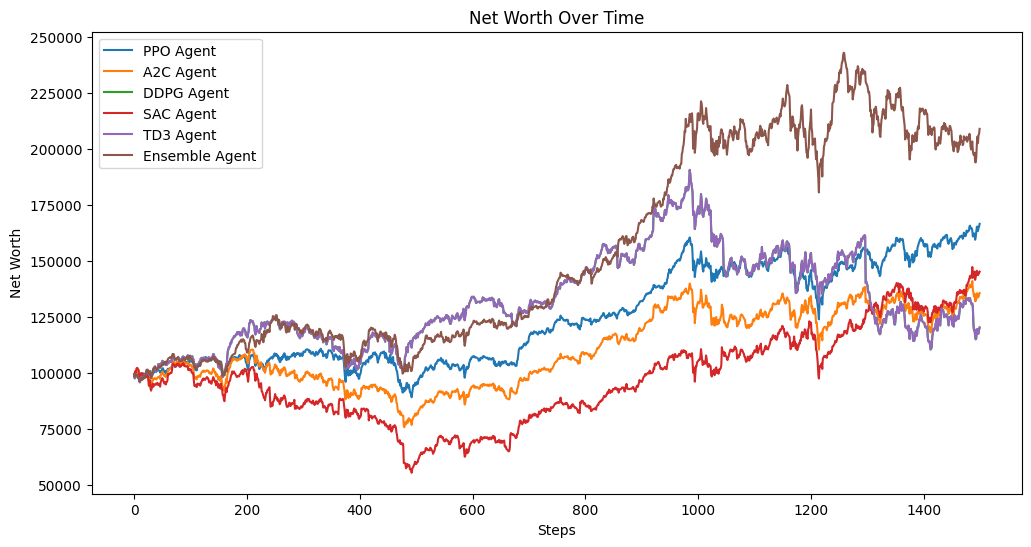

Testing PPO Agent...
Testing A2C Agent...
Testing DDPG Agent...
Testing SAC Agent...
Testing TD3 Agent...
Testing Ensemble Agent...


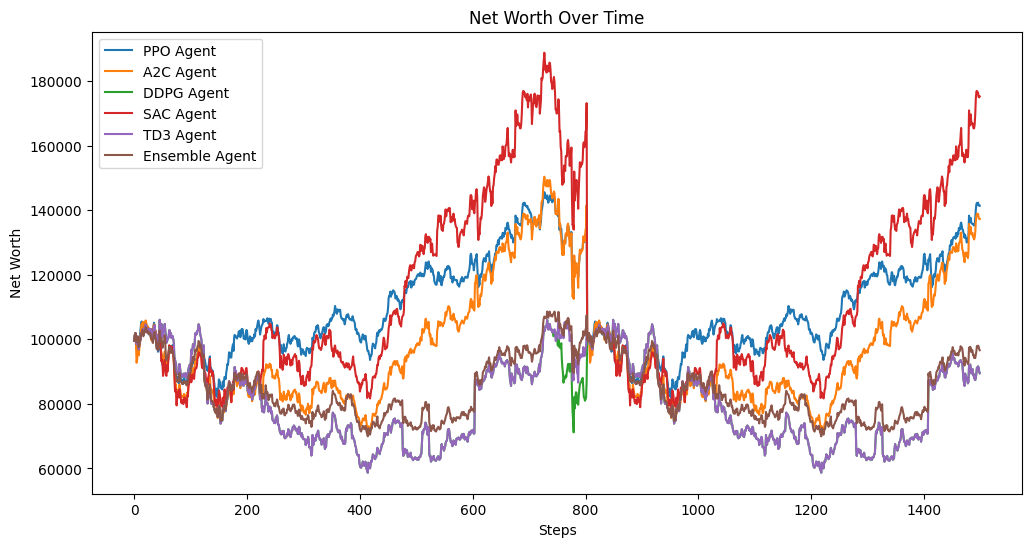

In [25]:
n_tests = 1500
agents = {
    'PPO Agent': ppo_agent,
    'A2C Agent': a2c_agent,
    'DDPG Agent': ddpg_agent,
    'SAC Agent': sac_agent,
    'TD3 Agent': td3_agent,
    'Ensemble Agent': ensemble_agent
}

test_and_visualize_agents(train_env, agents, training_data, n_tests=n_tests)

test_env = DummyVecEnv([lambda: StockTradingEnv(test_data, render_mode='human')])
test_and_visualize_agents(test_env, agents, test_data, n_tests=n_tests)

In [26]:
# Save these agent's metrics to test on more things
agent_metrics = {}
for name, agent in agents.items():
    agent_metrics[name] = test_agent(test_env, agent, test_data, n_tests=n_tests, visualize=False)
print("DONEEEEE!!!!")

DONEEEEE!!!!


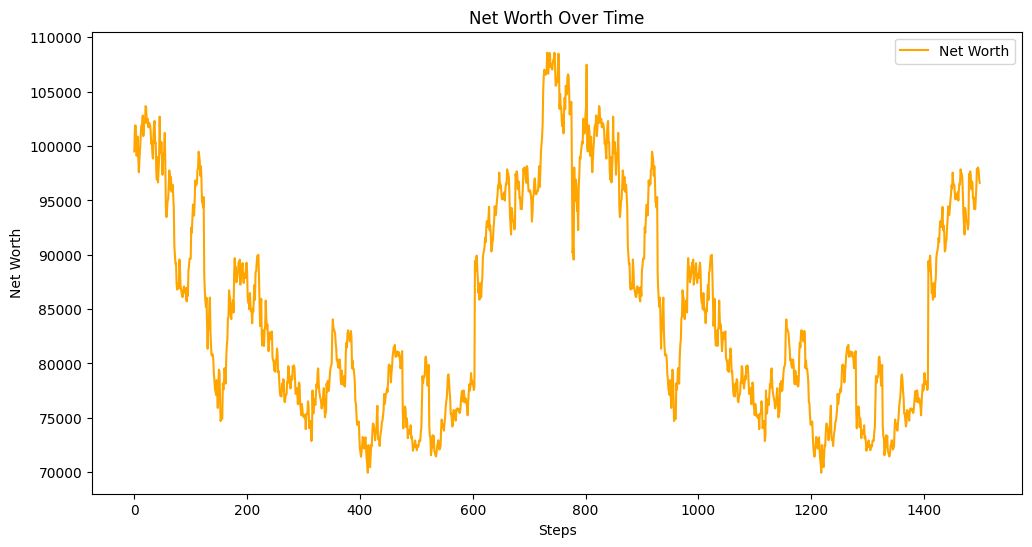

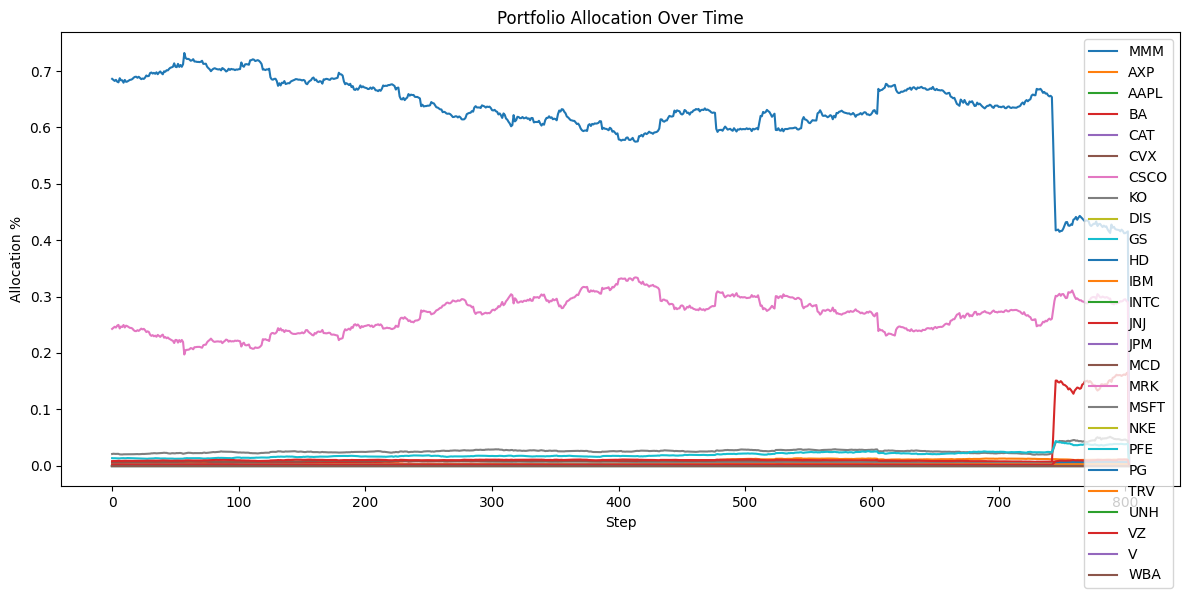

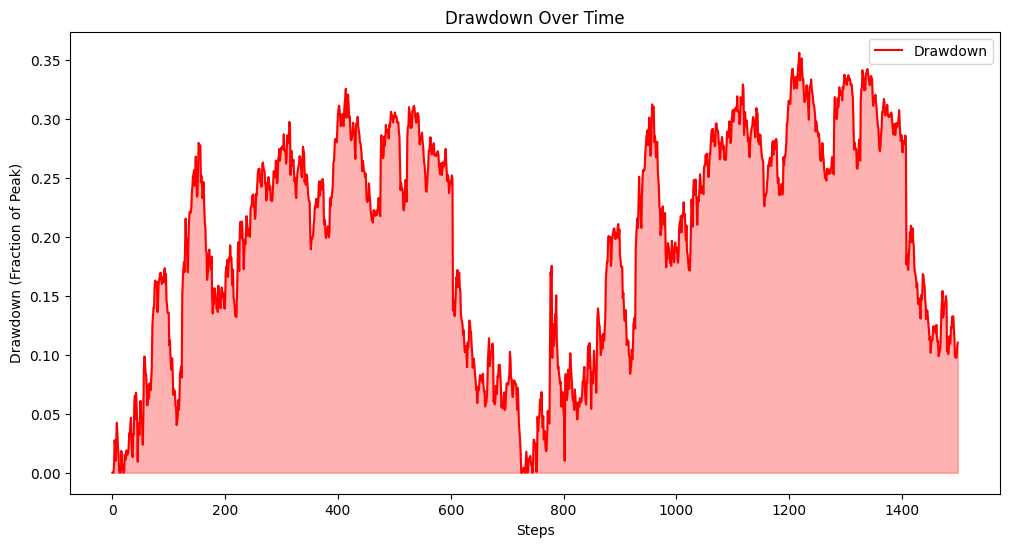

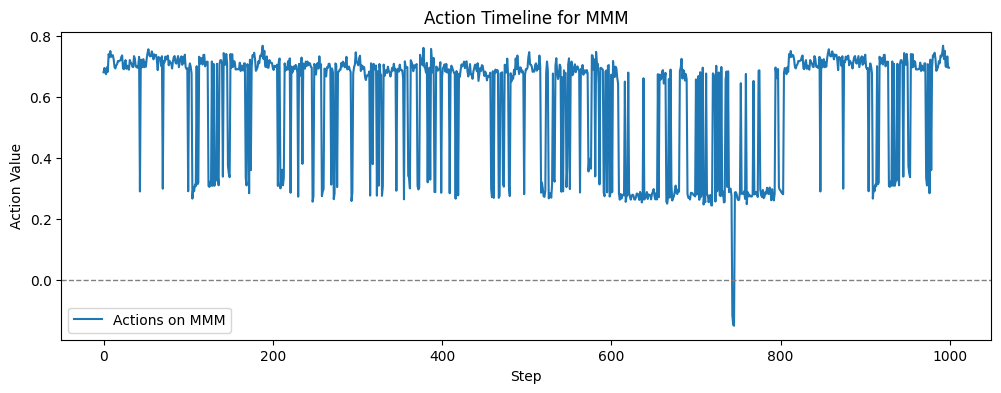

In [27]:
# Visualize detailed metrics for one agent (e.g., PPO)
selected_name = 'Ensemble Agent'
selected_metrics = agent_metrics[selected_name]

# Net Worth
visualize_portfolio_net_worth(selected_metrics['steps'], selected_metrics['net_worths'])

# Portfolio Allocation
visualize_portfolio_allocation(selected_metrics['steps'], selected_metrics['shares_held'], test_data)

# Drawdown
visualize_drawdown(selected_metrics['steps'], selected_metrics['net_worths'])

# Action Timeline for specific stock
visualize_actions(agents[selected_name], test_env, ticker="MMM", stock_data=test_data)


,Agent,Return,Standard Deviation,Sharpe Ratio
3,SAC Agent,0.000621,0.020949,0.029648
0,PPO Agent,0.000336,0.013904,0.024160
1,A2C Agent,0.000377,0.017659,0.021364
2,DDPG Agent,0.000130,0.020276,0.006429
5,Ensemble Agent,0.000091,0.014902,0.006075
4,TD3 Agent,0.000118,0.019597,0.006007


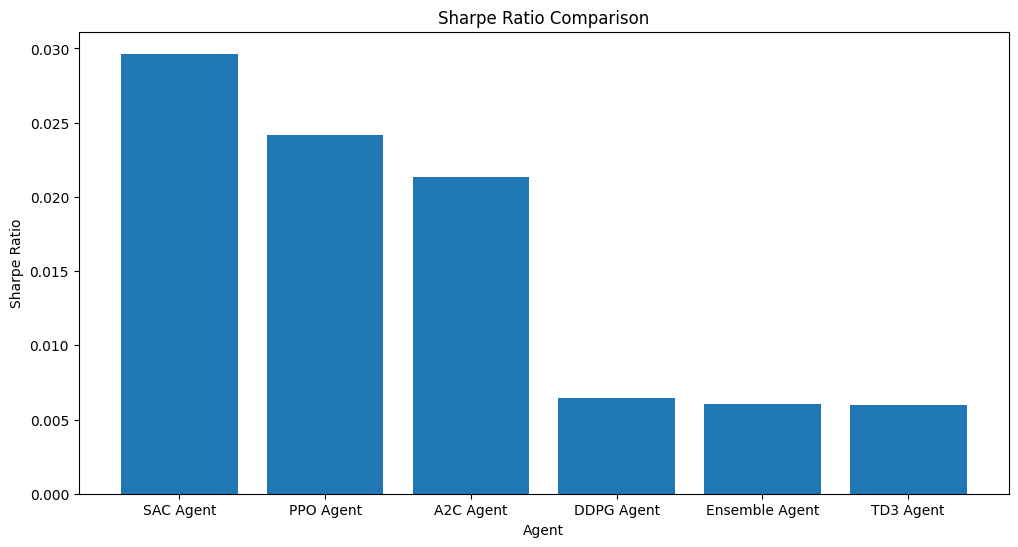

In [28]:
# 7. Comparison of All Agents
compare_and_plot_agents(list(agent_metrics.values()), list(agent_metrics.keys()))

In [29]:
def prepare_next_day_data(stock_data):
    """ Prepares the observation for the next trading day """

    # Initialize the environment with the current stock data
    env = StockTradingEnv(stock_data)
    env.reset()

    # Prepare the next day's observation
    next_day_observations = env._next_observation()

    return next_day_observations

def generate_next_day_recommendations(agents, next_day_observation):
    """ Generate recommendations for the next trading day using the trained agents """

    recommendations = {agent_name: [] for agent_name in agents.keys()}

    for agent_name, agent in agents.items():
        action = agent.predict(next_day_observation)
        recs = agent.action_to_recommendation(action)
        recommendations[agent_name] = zip(recs, action)

    return recommendations

# Prepare next day's observation
next_day_observation = prepare_next_day_data(test_data)

# Generate recommendations for the next trading day
recommendations = generate_next_day_recommendations(agents, next_day_observation)

# Print or display recommendations
for agent_name, recs in recommendations.items():
  if agent_name == 'Ensemble Agent':
      print(f'\nRecommendations for {agent_name}:')
      for ticker, recommendation in zip(tickers, recs):
          print(f"{ticker}: {recommendation}")


Recommendations for Ensemble Agent:
MMM: ('buy', 0.68151295)
AXP: ('hold', 0.02655363)
AAPL: ('hold', 0.003441119)
BA: ('hold', 0.022275735)
CAT: ('sell', -0.12062798)
CVX: ('hold', 0.021473873)
CSCO: ('buy', 0.81528664)
KO: ('buy', 0.39329624)
DIS: ('hold', 0.010073495)
GS: ('buy', 0.42190868)
HD: ('hold', 0.04326582)
IBM: ('sell', -0.3796685)
INTC: ('hold', 0.002067566)
JNJ: ('buy', 0.4210474)
JPM: ('hold', 0.020711899)
MCD: ('sell', -0.37861413)
MRK: ('hold', -0.0038912774)
MSFT: ('buy', 0.38025722)
NKE: ('buy', 0.17860064)
PFE: ('hold', 0.00892787)
PG: ('buy', 0.39913598)
TRV: ('buy', 0.3031435)
UNH: ('buy', 0.7879149)
VZ: ('buy', 0.644989)
V: ('hold', -0.025870372)
WBA: ('sell', -0.40844482)


# Reinforcement Learning Trading Assistant Chatbot 

In [30]:

def visualize_portfolio_wrapper():
    print("Visualizing full portfolio of PPO agent...")
    try:
        metrics = test_agent(test_env, ppo_agent, test_data, n_tests=500)
        visualize_portfolio(
            steps=metrics['steps'],
            balances=metrics['balances'],
            net_worths=metrics['net_worths'],
            shares_held=metrics['shares_held'],
            tickers=list(test_data.keys())
        )
    except Exception as e:
        print("Oh hell nah Error:", str(e))

def recommend_trades_wrapper():
    try:
        obs = test_env.reset()
        action = ensemble_agent.predict(obs)
        recs = ensemble_agent.action_to_recommendation(action)
        return f"Before we start, keep in mind I'm AI haha, but here are some trade recommendations: \n {dict(zip(tickers, recs))}"
    except Exception as e:
        return f"Oh nahh Error: {e}"

def test_all_agents_wrapper():
    try:
        test_and_visualize_agents(test_env, agents, test_data, n_tests=1500)
        return "All agents tested and visualized hehe."
    except Exception as e:
        return f"Oh noooooo Error: {e}"

def compare_agents_wrapper():
    try:
        test_metrics = [test_agent(test_env, agent, test_data, n_tests=1500) for agent in agents.values()]
        compare_and_plot_agents(test_metrics, list(agents.keys()))
        return "Agent comparison completed."
    except Exception as e:
        return f" Uh oh Error: {e}"

def parse_intent(message):
    message = message.lower()

    if "train" in message:
        for agent in ["ppo", "a2c", "ddpg", "sac", "td3"]:
            if agent in message:
                return "train_agent", agent

    if "evaluate" in message:
        for agent in ["ppo", "a2c", "ddpg", "sac", "td3", "ensemble"]:
            if agent in message:
                return "evaluate_agent", agent

    if "visualize" in message and "net worth" in message:
        return "visualize_net_worth", None

    if "visualize" in message and "portfolio" in message:
        return "visualize_portfolio", None

    if "recommend" in message:
        return "recommend_trades", None

    if "test" in message and "all" in message:
        return "test_all_agents", None

    if "compare" in message or "sharpe" in message:
        return "compare_agents", None

    if "help" in message:
        return "help", None

    return "unknown", None

def dispatch_intent(intent, target):
    if intent == "train_agent":
        agent_map = {
            "ppo": PPOAgent,
            "a2c": A2CAgent,
            "ddpg": DDPGAgent,
            "sac": SACAgent,
            "td3": TD3Agent
        }
        if target in agent_map:
            print(f"Training {target.upper()} agent...")
            agent = agent_map[target](train_env, total_timesteps=10000, threshold=0.1)
            globals()[f"{target}_agent"] = agent
            agent.validate(val_env)
        else:
            print("Agent type not recognized.")

    elif intent == "evaluate_agent":
        try:
            agent = globals()[f"{target}_agent"]
            print(f"Evaluating {target.upper()} agent...")
            agent.validate(test_env)
        except KeyError:
            print(f"{target.upper()} agent not trained or loaded.")

    elif intent == "visualize_net_worth":
        print("Visualizing net worth of PPO agent...")
        metrics = test_agent(test_env, ppo_agent, test_data, n_tests=500)
        visualize_portfolio_net_worth(metrics['steps'], metrics['net_worths'])

    elif intent == "visualize_portfolio":
        print(visualize_portfolio_wrapper())

    elif intent == "recommend_trades":
        print(recommend_trades_wrapper())

    elif intent == "test_all_agents":
        print(test_all_agents_wrapper())

    elif intent == "compare_agents":
        print(compare_agents_wrapper())

    elif intent == "help":
        print("""
Here are the list of commands you can tryyyy:
- "Train PPO agent"
- "Evaluate A2C"
- "Visualize net worth"
- "Visualize portfolio"
- "Recommend trades"
- "Compare agents"
- "Test all agents"
- "Quit"
        """)
    else:
        print("Uh oh I didn’t understand that. Try 'help' and come back to me later.")

# the chat loop
def rl_chatbot():
    print("Welcome to my RL Trading Assistant Chatbot, a cute smart assistant that can help you with your investment decision.")
    print("Type 'help' for options, or 'quit' to exit.")
    while True:
        message = input("What ya looking for?: ")
        if message.strip().lower() in ["quit", "exit"]:
            print("Bye Byeeeee!")
            break
        intent, target = parse_intent(message)
        dispatch_intent(intent, target)


Welcome to my RL Trading Assistant Chatbot, a cute smart assistant that can help you with your investment decision.
Type 'help' for options, or 'quit' to exit.


What ya looking for?:  help



You can try commands like:
- "Train PPO agent"
- "Evaluate A2C"
- "Visualize net worth"
- "Visualize portfolio"
- "Recommend trades"
- "Compare agents"
- "Test all agents"
- "Quit"
        


What ya looking for?:  Recommend trades


Before we start, keep in mind I'm AI haha, but here are some trade recommendations: 
 {'MMM': 'buy', 'AXP': 'hold', 'AAPL': 'hold', 'BA': 'hold', 'CAT': 'sell', 'CVX': 'hold', 'CSCO': 'buy', 'KO': 'buy', 'DIS': 'hold', 'GS': 'buy', 'HD': 'hold', 'IBM': 'sell', 'INTC': 'hold', 'JNJ': 'buy', 'JPM': 'hold', 'MCD': 'sell', 'MRK': 'hold', 'MSFT': 'buy', 'NKE': 'buy', 'PFE': 'hold', 'PG': 'buy', 'TRV': 'buy', 'UNH': 'buy', 'VZ': 'buy', 'V': 'hold', 'WBA': 'sell'}


What ya looking for?:  visualize net worth


Visualizing net worth of PPO agent...


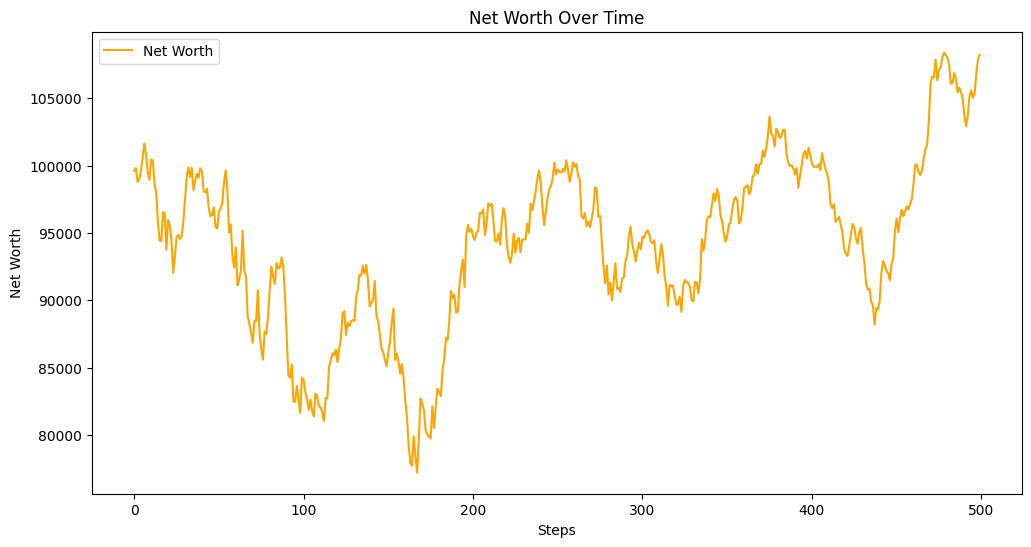

What ya looking for?:  compare agents


,Agent,Return,Standard Deviation,Sharpe Ratio
3,SAC Agent,0.000434,0.019309,0.022462
0,PPO Agent,0.000256,0.013011,0.019671
1,A2C Agent,0.000241,0.016248,0.014860
2,DDPG Agent,0.000097,0.022568,0.004315
4,TD3 Agent,0.000058,0.020257,0.002881
5,Ensemble Agent,0.000028,0.014958,0.001854


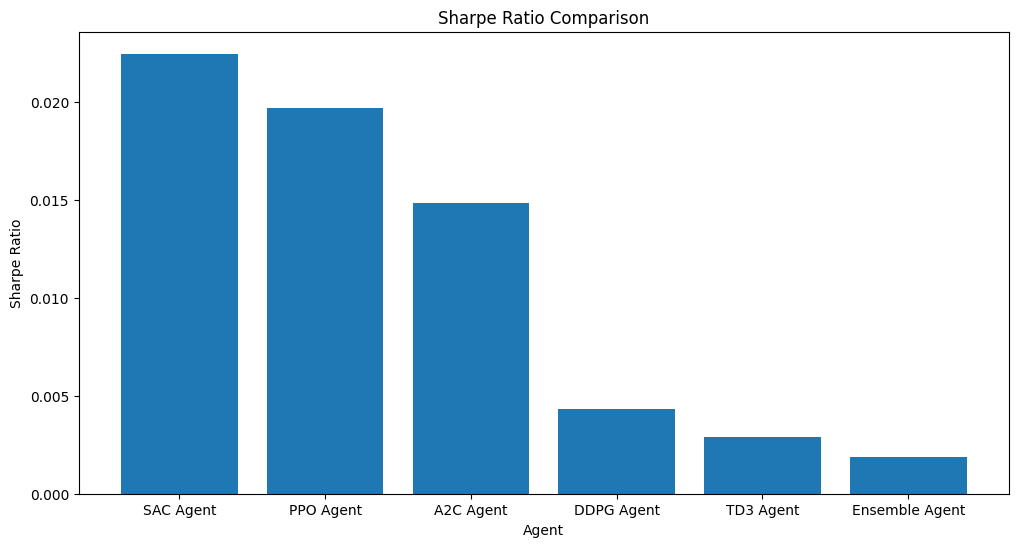

Agent comparison completed.


What ya looking for?:  quit


Bye Byeeeee!


In [216]:
# launching chatbot
rl_chatbot()